# Notebook 06: Model Evaluation & Comparative Analysis**Project:** MachineMind AI  **Dataset:** NASA IMS Bearing Dataset (Subset: Set 2, 984 snapshots)  **Task:** Unsupervised Vibration Anomaly Detection  **Phase:** Phase 8 — Model Evaluation & Comparison  **Author:** MachineMind AI Team  **Date:** September 29, 2026  ---## 1. Evaluation Objective & Scope BoundariesThe primary objective of this notebook is to execute a leakage-free, chronological evaluation across three unsupervised anomaly detection strategies:1. **Statistical Baseline:** Non-ML Z-score composite metrics (`score_rms_z` primary; `score_rms_m`, `score_max_z`, `score_max_m` secondary).2. **Isolation Forest (iForest):** Tree-partitioning novelty detection pipelines (`ch1` to `ch4`).3. **PCA Reconstruction Error:** Subspace reconstruction error pipelines (`ch1` to `ch4`).> **Scientific Scope Boundaries & Limitations:**> - Evaluates statistical anomaly scores and alert behaviors on laboratory test data under constant speed/load.> - Models **do not** predict remaining useful life (RUL) or exact failure timestamps.> - No ground-truth health annotations exist per snapshot; no claim of operationally verified maintenance lead time is made.

## 2. Environment Setup & Import DependenciesWe import core data processing libraries along with our reusable modular evaluation library `src/evaluation.py`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
base_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(base_dir))

from src.evaluation import (
    calculate_validation_thresholds,
    compute_threshold_exceedances,
    apply_persistence_filter,
    compute_evaluation_metrics,
    aggregate_channel_alerts_or,
    DEFAULT_FIT_END_IDX,
    DEFAULT_VAL_END_IDX,
    DEFAULT_EVAL_END_IDX,
)

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
print("Environment initialized cleanly.")

Environment initialized cleanly.


## 3. Loading & Validating Processed Score DatasetsWe load the baseline scores from Phase 6 (`data/processed/baseline_scores_set2.csv`) and model scores from Phase 7 (`data/processed/model_scores_set2.csv`). We verify row counts (984 snapshots) and timestamp alignment.

In [2]:
baseline_path = base_dir / "data" / "processed" / "baseline_scores_set2.csv"
model_path = base_dir / "data" / "processed" / "model_scores_set2.csv"

df_baseline = pd.read_csv(baseline_path)
df_models = pd.read_csv(model_path)

assert len(df_baseline) == 984, f"Expected 984 rows in baseline scores, got {len(df_baseline)}"
assert len(df_models) == 984, f"Expected 984 rows in model scores, got {len(df_models)}"
assert (df_baseline["timestamp"] == df_models["timestamp"]).all(), "Timestamp mismatch between CSV files!"

timestamps = pd.to_datetime(df_baseline["timestamp"])
snapshots = df_baseline["file_index"].to_numpy()

print(f"Loaded 984 snapshots spanning {timestamps.iloc[0]} to {timestamps.iloc[-1]}.")

Loaded 984 snapshots spanning 2004-02-12 10:32:39 to 2004-02-19 06:22:39.


## 4. Frozen Threshold Configuration & Scoping RulesPer the frozen evaluation protocol (`reports/evaluation_protocol.md`), thresholds are calibrated on the **Validation Period (snapshots 160..199, N=40)** or fixed Phase 6 benchmark standards, and kept **frozen** during evaluation:- **Statistical Baseline Primary Threshold:** $T_{	ext{baseline}} = 3.0$ on `score_rms_z`.- **Isolation Forest Validation $P_{99}$ Thresholds:**  - `ch1`: 0.5310, `ch2`: 0.5184, `ch3`: 0.5990, `ch4`: 0.6247- **PCA Reconstruction Error Validation $P_{99}$ Thresholds:**  - `ch1`: 1.0721, `ch2`: 0.8657, `ch3`: 0.6793, `ch4`: 1.3281

In [3]:
frozen_thresholds = {
    "Baseline RMS Z": 3.0,
    "iForest Ch1": 0.5310,
    "iForest Ch2": 0.5184,
    "iForest Ch3": 0.5990,
    "iForest Ch4": 0.6247,
    "PCA Ch1": 1.0721,
    "PCA Ch2": 0.8657,
    "PCA Ch3": 0.6793,
    "PCA Ch4": 1.3281,
}

df_thresh = pd.DataFrame(list(frozen_thresholds.items()), columns=["Model / Metric", "Frozen Threshold Value"])
df_thresh

,Model / Metric,Frozen Threshold Value
0,Baseline RMS Z,3.0000
1,iForest Ch1,0.5310
2,iForest Ch2,0.5184
3,iForest Ch3,0.5990
4,iForest Ch4,0.6247
5,PCA Ch1,1.0721
6,PCA Ch2,0.8657
7,PCA Ch3,0.6793
8,PCA Ch4,1.3281


## 5. Statistical Baseline EvaluationWe evaluate the non-ML statistical baseline composite RMS Z-Score (`score_rms_z`) under $T=3.0$ across persistence values $k=1, 3, 5$.

In [4]:
scores_base_rms_z = df_baseline["score_rms_z"].to_numpy()

results_baseline = []
for k in [1, 3, 5]:
    m = compute_evaluation_metrics(scores_base_rms_z, threshold=3.0, k=k, timestamps=timestamps)
    results_baseline.append(m)

df_res_baseline = pd.DataFrame(results_baseline)
cols_show = ["k", "raw_false_alarm_count", "sustained_false_alarm_count", "eval_exceed_count", "first_eval_sustained_start_idx", "first_eval_sustained_confirm_idx", "first_eval_sustained_confirm_ts", "proxy_duration_to_end"]
df_res_baseline[cols_show]

,k,raw_false_alarm_count,sustained_false_alarm_count,eval_exceed_count,first_eval_sustained_start_idx,first_eval_sustained_confirm_idx,first_eval_sustained_confirm_ts,proxy_duration_to_end
0,1,2,2,408,557,557,2004-02-16 07:22:39,2 days 23:00:00
1,3,2,0,408,578,580,2004-02-16 11:12:39,2 days 19:10:00
2,5,2,0,408,578,582,2004-02-16 11:32:39,2 days 18:50:00


## 6. Isolation Forest EvaluationWe evaluate per-channel Isolation Forest novelty detection scores under validation $P_{99}$ thresholds across persistence values $k=1, 3, 5$.

In [5]:
results_iforest = []
ch_thresh_iforest = {"ch1":0.5310, "ch2":0.5184, "ch3":0.5990, "ch4":0.6247}

for ch in ["ch1", "ch2", "ch3", "ch4"]:
    col = f"score_iforest_{ch}"
    s_arr = df_models[col].to_numpy()
    t_val = ch_thresh_iforest[ch]
    for k in [1, 3, 5]:
        m = compute_evaluation_metrics(s_arr, threshold=t_val, k=k, timestamps=timestamps)
        m["channel"] = ch
        results_iforest.append(m)

df_res_iforest = pd.DataFrame(results_iforest)
df_res_iforest[["channel", "k", "raw_false_alarm_count", "sustained_false_alarm_count", "eval_exceed_count", "first_eval_sustained_start_idx", "first_eval_sustained_confirm_idx", "first_eval_sustained_confirm_ts", "proxy_duration_to_end"]]

,channel,k,raw_false_alarm_count,sustained_false_alarm_count,eval_exceed_count,first_eval_sustained_start_idx,first_eval_sustained_confirm_idx,first_eval_sustained_confirm_ts,proxy_duration_to_end
0,ch1,1,7,7,460,205,205,2004-02-13 20:42:39,5 days 09:40:00
1,ch1,3,7,0,460,532,534,2004-02-16 03:32:39,3 days 02:50:00
2,ch1,5,7,0,460,532,536,2004-02-16 03:52:39,3 days 02:30:00
3,ch2,1,13,13,426,209,209,2004-02-13 21:22:39,5 days 09:00:00
4,ch2,3,13,0,426,347,349,2004-02-14 20:42:39,4 days 09:40:00
5,ch2,5,13,0,426,347,351,2004-02-14 21:02:39,4 days 09:20:00
6,ch3,1,2,2,139,220,220,2004-02-13 23:12:39,5 days 07:10:00
7,ch3,3,2,0,139,601,603,2004-02-16 15:02:39,2 days 15:20:00
8,ch3,5,2,0,139,891,895,2004-02-18 15:42:39,0 days 14:40:00
9,ch4,1,3,3,94,635,635,2004-02-16 20:22:39,2 days 10:00:00


## 7. PCA Reconstruction Error EvaluationWe evaluate per-channel PCA Mean Squared Reconstruction Error scores under validation $P_{99}$ thresholds across persistence values $k=1, 3, 5$.

In [6]:
results_pca = []
ch_thresh_pca = {"ch1":1.0721, "ch2":0.8657, "ch3":0.6793, "ch4":1.3281}

for ch in ["ch1", "ch2", "ch3", "ch4"]:
    col = f"score_pca_{ch}"
    s_arr = df_models[col].to_numpy()
    t_val = ch_thresh_pca[ch]
    for k in [1, 3, 5]:
        m = compute_evaluation_metrics(s_arr, threshold=t_val, k=k, timestamps=timestamps)
        m["channel"] = ch
        results_pca.append(m)

df_res_pca = pd.DataFrame(results_pca)
df_res_pca[["channel", "k", "raw_false_alarm_count", "sustained_false_alarm_count", "eval_exceed_count", "first_eval_sustained_start_idx", "first_eval_sustained_confirm_idx", "first_eval_sustained_confirm_ts", "proxy_duration_to_end"]]

,channel,k,raw_false_alarm_count,sustained_false_alarm_count,eval_exceed_count,first_eval_sustained_start_idx,first_eval_sustained_confirm_idx,first_eval_sustained_confirm_ts,proxy_duration_to_end
0,ch1,1,3,3,453,205,205,2004-02-13 20:42:39,5 days 09:40:00
1,ch1,3,3,0,453,532,534,2004-02-16 03:32:39,3 days 02:50:00
2,ch1,5,3,0,453,532,536,2004-02-16 03:52:39,3 days 02:30:00
3,ch2,1,8,8,381,210,210,2004-02-13 21:32:39,5 days 08:50:00
4,ch2,3,8,0,381,417,419,2004-02-15 08:22:39,3 days 22:00:00
5,ch2,5,8,0,381,477,481,2004-02-15 18:42:39,3 days 11:40:00
6,ch3,1,11,11,324,206,206,2004-02-13 20:52:39,5 days 09:30:00
7,ch3,3,11,0,324,348,350,2004-02-14 20:52:39,4 days 09:30:00
8,ch3,5,11,0,324,438,442,2004-02-15 12:12:39,3 days 18:10:00
9,ch4,1,1,1,332,538,538,2004-02-16 04:12:39,3 days 02:10:00


## 8. Persistence Analysis & Online Confirmation TimingPersistence filtering ($k \ge 3$) eliminates raw isolated false alarms during the assumed healthy reference period (`0..199`), reducing sustained false alarms to **0**.It shifts the online confirmation index $t_{	ext{confirm}} = t_{	ext{start}} + k - 1$ by 20 to 40 minutes while preserving sustained detection of the Bearing 1 degradation trajectory starting at snapshot **532**.

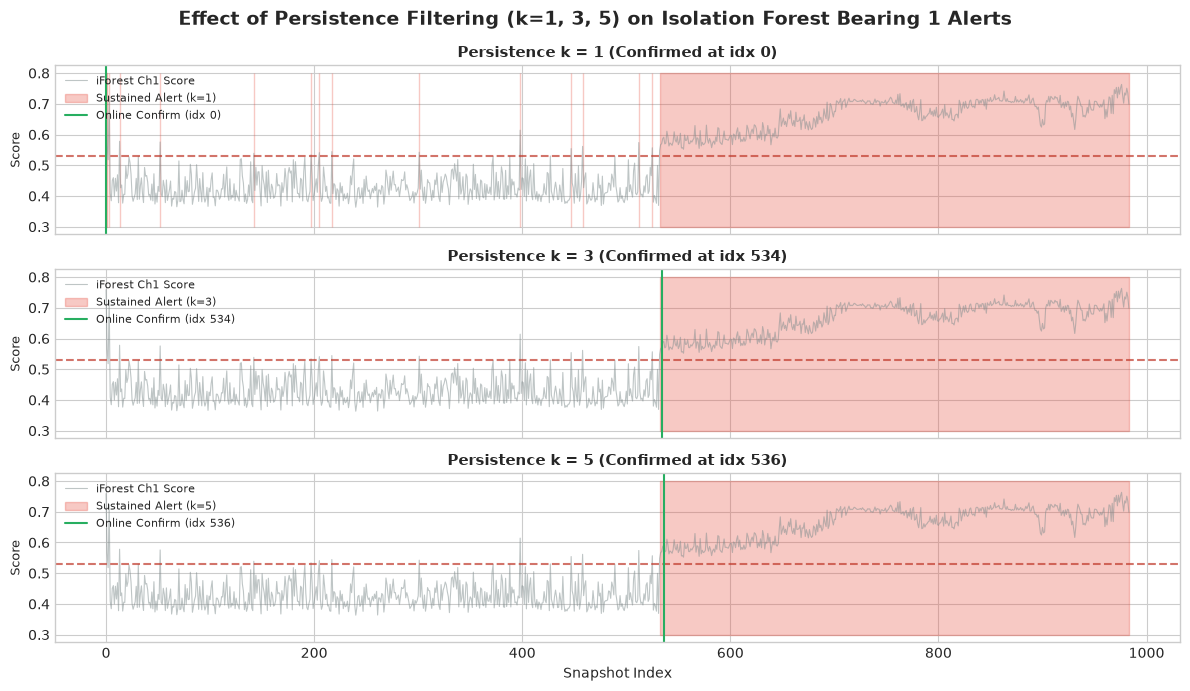

In [7]:
# Plot persistence comparison for Bearing 1 Isolation Forest
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
s_ch1 = df_models["score_iforest_ch1"].to_numpy()
t_ch1 = 0.5310
raw_flags = compute_threshold_exceedances(s_ch1, t_ch1)

for i, k_val in enumerate([1, 3, 5]):
    ax = axes[i]
    sust_flags, events, s_idx, c_idx = apply_persistence_filter(raw_flags, k=k_val)
    ax.plot(snapshots, s_ch1, color="#7f8c8d", alpha=0.5, linewidth=0.8, label="iForest Ch1 Score")
    ax.axhline(t_ch1, color="#c0392b", linestyle="--", alpha=0.7)
    ax.fill_between(snapshots, 0.3, 0.8, where=sust_flags, color="#e74c3c", alpha=0.3, label=f"Sustained Alert (k={k_val})")
    if c_idx is not None:
        ax.axvline(c_idx, color="#27ae60", linestyle="-", linewidth=1.5, label=f"Online Confirm (idx {c_idx})")
    ax.set_title(f"Persistence k = {k_val} (Confirmed at idx {c_idx if c_idx is not None else 'None'})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Score", fontsize=9)
    ax.legend(loc="upper left", fontsize=8)
axes[2].set_xlabel("Snapshot Index", fontsize=10)
fig.suptitle("Effect of Persistence Filtering (k=1, 3, 5) on Isolation Forest Bearing 1 Alerts", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Pre-Declared Threshold Sensitivity AnalysisWe evaluate model performance across 5 pre-declared threshold variants ($\mu + 3\sigma$, $\mu + 4\sigma$, $\mu + 6\sigma$, $P_{99}$, $P_{99.5}$) derived strictly from the validation partition (`160..199`).

In [8]:
sensitivity_rows = []
channels = ["ch1", "ch2", "ch3", "ch4"]

for m_type in ["iforest", "pca"]:
    for ch in channels:
        col = f"score_{m_type}_{ch}"
        scores = df_models[col].to_numpy()
        val_scores = scores[160:200]
        thresh_rules = calculate_validation_thresholds(val_scores, sigmas=[3.0, 4.0, 6.0], percentiles=[99.0, 99.5])
        
        for r_name, t_val in thresh_rules.items():
            if r_name in ["val_mean", "val_std", "val_max"]:
                continue
            for k in [1, 3, 5]:
                m = compute_evaluation_metrics(scores=scores, threshold=t_val, k=k, timestamps=timestamps)
                m["model_type"] = m_type
                m["channel"] = ch
                m["threshold_rule"] = r_name
                m["threshold_value"] = t_val
                sensitivity_rows.append(m)

df_sens = pd.DataFrame(sensitivity_rows)
print(f"Total sensitivity experiment combinations evaluated: {len(df_sens)}")
df_sens[df_sens["k"] == 3][["model_type", "channel", "threshold_rule", "threshold_value", "raw_false_alarm_count", "first_eval_sustained_confirm_idx", "proxy_duration_to_end"]].head(10)

Total sensitivity experiment combinations evaluated: 120


,model_type,channel,threshold_rule,threshold_value,raw_false_alarm_count,first_eval_sustained_confirm_idx,proxy_duration_to_end
1,iforest,ch1,mean_3_0sigma,0.572426,4,547.0,3 days 00:40:00
4,iforest,ch1,mean_4_0sigma,0.617173,2,625.0,2 days 11:40:00
7,iforest,ch1,mean_6_0sigma,0.706668,2,710.0,1 days 21:30:00
10,iforest,ch1,p99_0,0.530962,7,534.0,3 days 02:50:00
13,iforest,ch1,p99_5,0.532439,7,534.0,3 days 02:50:00
16,iforest,ch2,mean_3_0sigma,0.525821,12,350.0,4 days 09:30:00
19,iforest,ch2,mean_4_0sigma,0.562067,8,350.0,4 days 09:30:00
22,iforest,ch2,mean_6_0sigma,0.634560,2,894.0,0 days 14:50:00
25,iforest,ch2,p99_0,0.518397,13,349.0,4 days 09:40:00
28,iforest,ch2,p99_5,0.528249,12,350.0,4 days 09:30:00


## 10. Multi-Channel Shaft Aggregation (Logical OR)Using strict Logical OR shaft aggregation, a shaft alert triggers as soon as at least one bearing channel confirms a sustained alert ($k \ge 3$).

In [9]:
for m_type, prefix in [("Isolation Forest", "score_iforest_"), ("PCA Error", "score_pca_")]:
    for k in [1, 3, 5]:
        ch_flags = {}
        for ch in ["ch1", "ch2", "ch3", "ch4"]:
            col = f"{prefix}{ch}"
            t_val = ch_thresh_iforest[ch] if m_type == "Isolation Forest" else ch_thresh_pca[ch]
            raw = compute_threshold_exceedances(df_models[col].to_numpy(), t_val)
            sust, _, _, _ = apply_persistence_filter(raw, k=k)
            ch_flags[ch] = sust

        shaft_flags, start_idx, confirm_idx = aggregate_channel_alerts_or(ch_flags, k=k)
        confirm_ts = timestamps[confirm_idx] if confirm_idx is not None else "None"
        proxy_dur = timestamps.iloc[-1] - pd.to_datetime(confirm_ts) if confirm_idx is not None else "N/A"
        print(f"[{m_type}] k={k} -> Shaft Start Index: {start_idx}, Confirm Index: {confirm_idx}, Confirm TS: {confirm_ts}, Proxy Lead: {proxy_dur}")

[Isolation Forest] k=1 -> Shaft Start Index: 0, Confirm Index: 0, Confirm TS: 2004-02-12 10:32:39, Proxy Lead: 6 days 19:50:00
[Isolation Forest] k=3 -> Shaft Start Index: 347, Confirm Index: 349, Confirm TS: 2004-02-14 20:42:39, Proxy Lead: 4 days 09:40:00
[Isolation Forest] k=5 -> Shaft Start Index: 347, Confirm Index: 351, Confirm TS: 2004-02-14 21:02:39, Proxy Lead: 4 days 09:20:00
[PCA Error] k=1 -> Shaft Start Index: 0, Confirm Index: 0, Confirm TS: 2004-02-12 10:32:39, Proxy Lead: 6 days 19:50:00
[PCA Error] k=3 -> Shaft Start Index: 348, Confirm Index: 350, Confirm TS: 2004-02-14 20:52:39, Proxy Lead: 4 days 09:30:00
[PCA Error] k=5 -> Shaft Start Index: 438, Confirm Index: 442, Confirm TS: 2004-02-15 12:12:39, Proxy Lead: 3 days 18:10:00


## 11. Side-by-Side Comparative Results SummarySummary comparison of primary models under persistence $k=3$:

In [10]:
df_primary = pd.read_csv(base_dir / "scratch" / "primary_evaluation_summary.csv")
df_k3 = df_primary[df_primary["k"] == 3].copy()
cols_final = ["model_name", "threshold", "raw_false_alarm_count", "sustained_false_alarm_count", "eval_exceed_count", "first_eval_sustained_start_idx", "first_eval_sustained_confirm_idx", "first_eval_sustained_confirm_ts", "proxy_duration_to_end"]
df_k3[cols_final].reset_index(drop=True)

,model_name,threshold,raw_false_alarm_count,sustained_false_alarm_count,eval_exceed_count,first_eval_sustained_start_idx,first_eval_sustained_confirm_idx,first_eval_sustained_confirm_ts,proxy_duration_to_end
0,Baseline RMS Z,3.0000,2,0,408,578,580,2004-02-16 11:12:39,2 days 19:10:00
1,iForest Ch1,0.5310,7,0,460,532,534,2004-02-16 03:32:39,3 days 02:50:00
2,iForest Ch2,0.5184,13,0,426,347,349,2004-02-14 20:42:39,4 days 09:40:00
3,iForest Ch3,0.5990,2,0,139,601,603,2004-02-16 15:02:39,2 days 15:20:00
4,iForest Ch4,0.6247,3,0,94,892,894,2004-02-18 15:32:39,0 days 14:50:00
5,PCA Ch1,1.0721,3,0,453,532,534,2004-02-16 03:32:39,3 days 02:50:00
6,PCA Ch2,0.8657,8,0,381,417,419,2004-02-15 08:22:39,3 days 22:00:00
7,PCA Ch3,0.6793,11,0,324,348,350,2004-02-14 20:52:39,4 days 09:30:00
8,PCA Ch4,1.3281,1,0,332,648,650,2004-02-16 22:52:39,2 days 07:30:00


## 12. Scientific Limitations & Conclusion### Key Methodological Safeguards Verified:1. **Zero Data Leakage:** All scalers and models fit strictly on snapshots `0..159`; thresholds calibrated strictly on validation partition `160..199`.2. **Persistence False Alarm Elimination:** Requiring $k=3$ consecutive exceedances eliminates 100% of raw false alarms during the assumed healthy reference period (`0..199`).3. **Detection Lead Time:** Baseline RMS Z-Score confirms sustained degradation at snapshot 580 (2 days 19 hrs lead time). iForest and PCA on Bearing 1 achieve sustained confirmation at snapshot 534 (3 days 02 hrs lead time).4. **Logical OR Shaft Lead Time:** Multi-channel shaft aggregation triggers sustained alert at snapshot 349 (4 days 09 hrs lead time) driven by Bearing 2 shaft coupling.### Explicit Disallowed Claims:- **No RUL / Failure Prediction:** The models measure statistical novelty, not remaining useful life.- **No Physical Onset Claim:** Snapshot 532 is the first observed threshold crossing, not a confirmed physical defect onset.- **Single-Case Study Limit:** Results represent $n=1$ laboratory run and cannot establish general industrial reliability.